## code from https://github.com/nattaponm/radar_mosaic_thai_SF66/blob/main/15%E0%B8%9E%E0%B8%A5%E0%B8%AD%E0%B8%95%E0%B9%81%E0%B8%9C%E0%B8%99%E0%B8%97%E0%B8%B5%E0%B9%88GIS%E0%B9%83%E0%B8%99%E0%B8%A5%E0%B8%B8%E0%B9%88%E0%B8%A1%E0%B8%99%E0%B9%89%E0%B8%B3%E0%B8%AB%E0%B8%A5%E0%B8%B1%E0%B8%81%E0%B9%81%E0%B8%A5%E0%B8%B0%E0%B8%A2%E0%B9%88%E0%B8%AD%E0%B8%A2%E0%B8%82%E0%B8%AD%E0%B8%87%E0%B8%9D%E0%B8%99%E0%B9%80%E0%B8%A3%E0%B8%94%E0%B8%B2%E0%B8%A3%E0%B9%8C%E0%B9%81%E0%B8%A5%E0%B8%B0%E0%B9%81%E0%B8%9A%E0%B8%9A8%E0%B8%A0%E0%B8%B2%E0%B8%9E%E0%B8%A2%E0%B9%88%E0%B8%AD%E0%B8%A2_%E0%B8%9A%E0%B8%B1%E0%B8%99%E0%B8%97%E0%B8%B6%E0%B8%81%E0%B9%80%E0%B8%9B%E0%B9%87%E0%B8%99shapefile%E0%B9%84%E0%B8%94%E0%B9%89.ipynb

Mounted at /content/drive
Checking paths...
DATA_ROOT exists    : True
BASE_DIR exists     : True
SHAPEFILE exists    : True
Target .tif exists  : True
Target file         : /content/drive/MyDrive/1shared_etc/000อบรมเรดาร์กรมชลประทาน/0data_radar_mos/0radar_mosaic_geotif_samples/0mfb/2018071722.tif
GeoTIFF files found : 48
First file          : 2018071700.tif
Last file           : 2018071823.tif
✅ Loading: 2018071722.tif ...
✅ Map saved to: /content/drive/MyDrive/1shared_etc/000อบรมเรดาร์กรมชลประทาน/0data_radar_mos/0zonal_stats_output/0hourly_mapplot/2018071722.png
✅ Shapefile saved to: /content/drive/MyDrive/1shared_etc/000อบรมเรดาร์กรมชลประทาน/0data_radar_mos/0zonal_stats_output/0hourly_shapefile/2018071722.shp


/tmp/ipykernel_296/3596530290.py:175: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  sub_basins_with_stats.to_file(shapefile_output)
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'mean_rainfall' to 'mean_rainf'
  ogr_write(


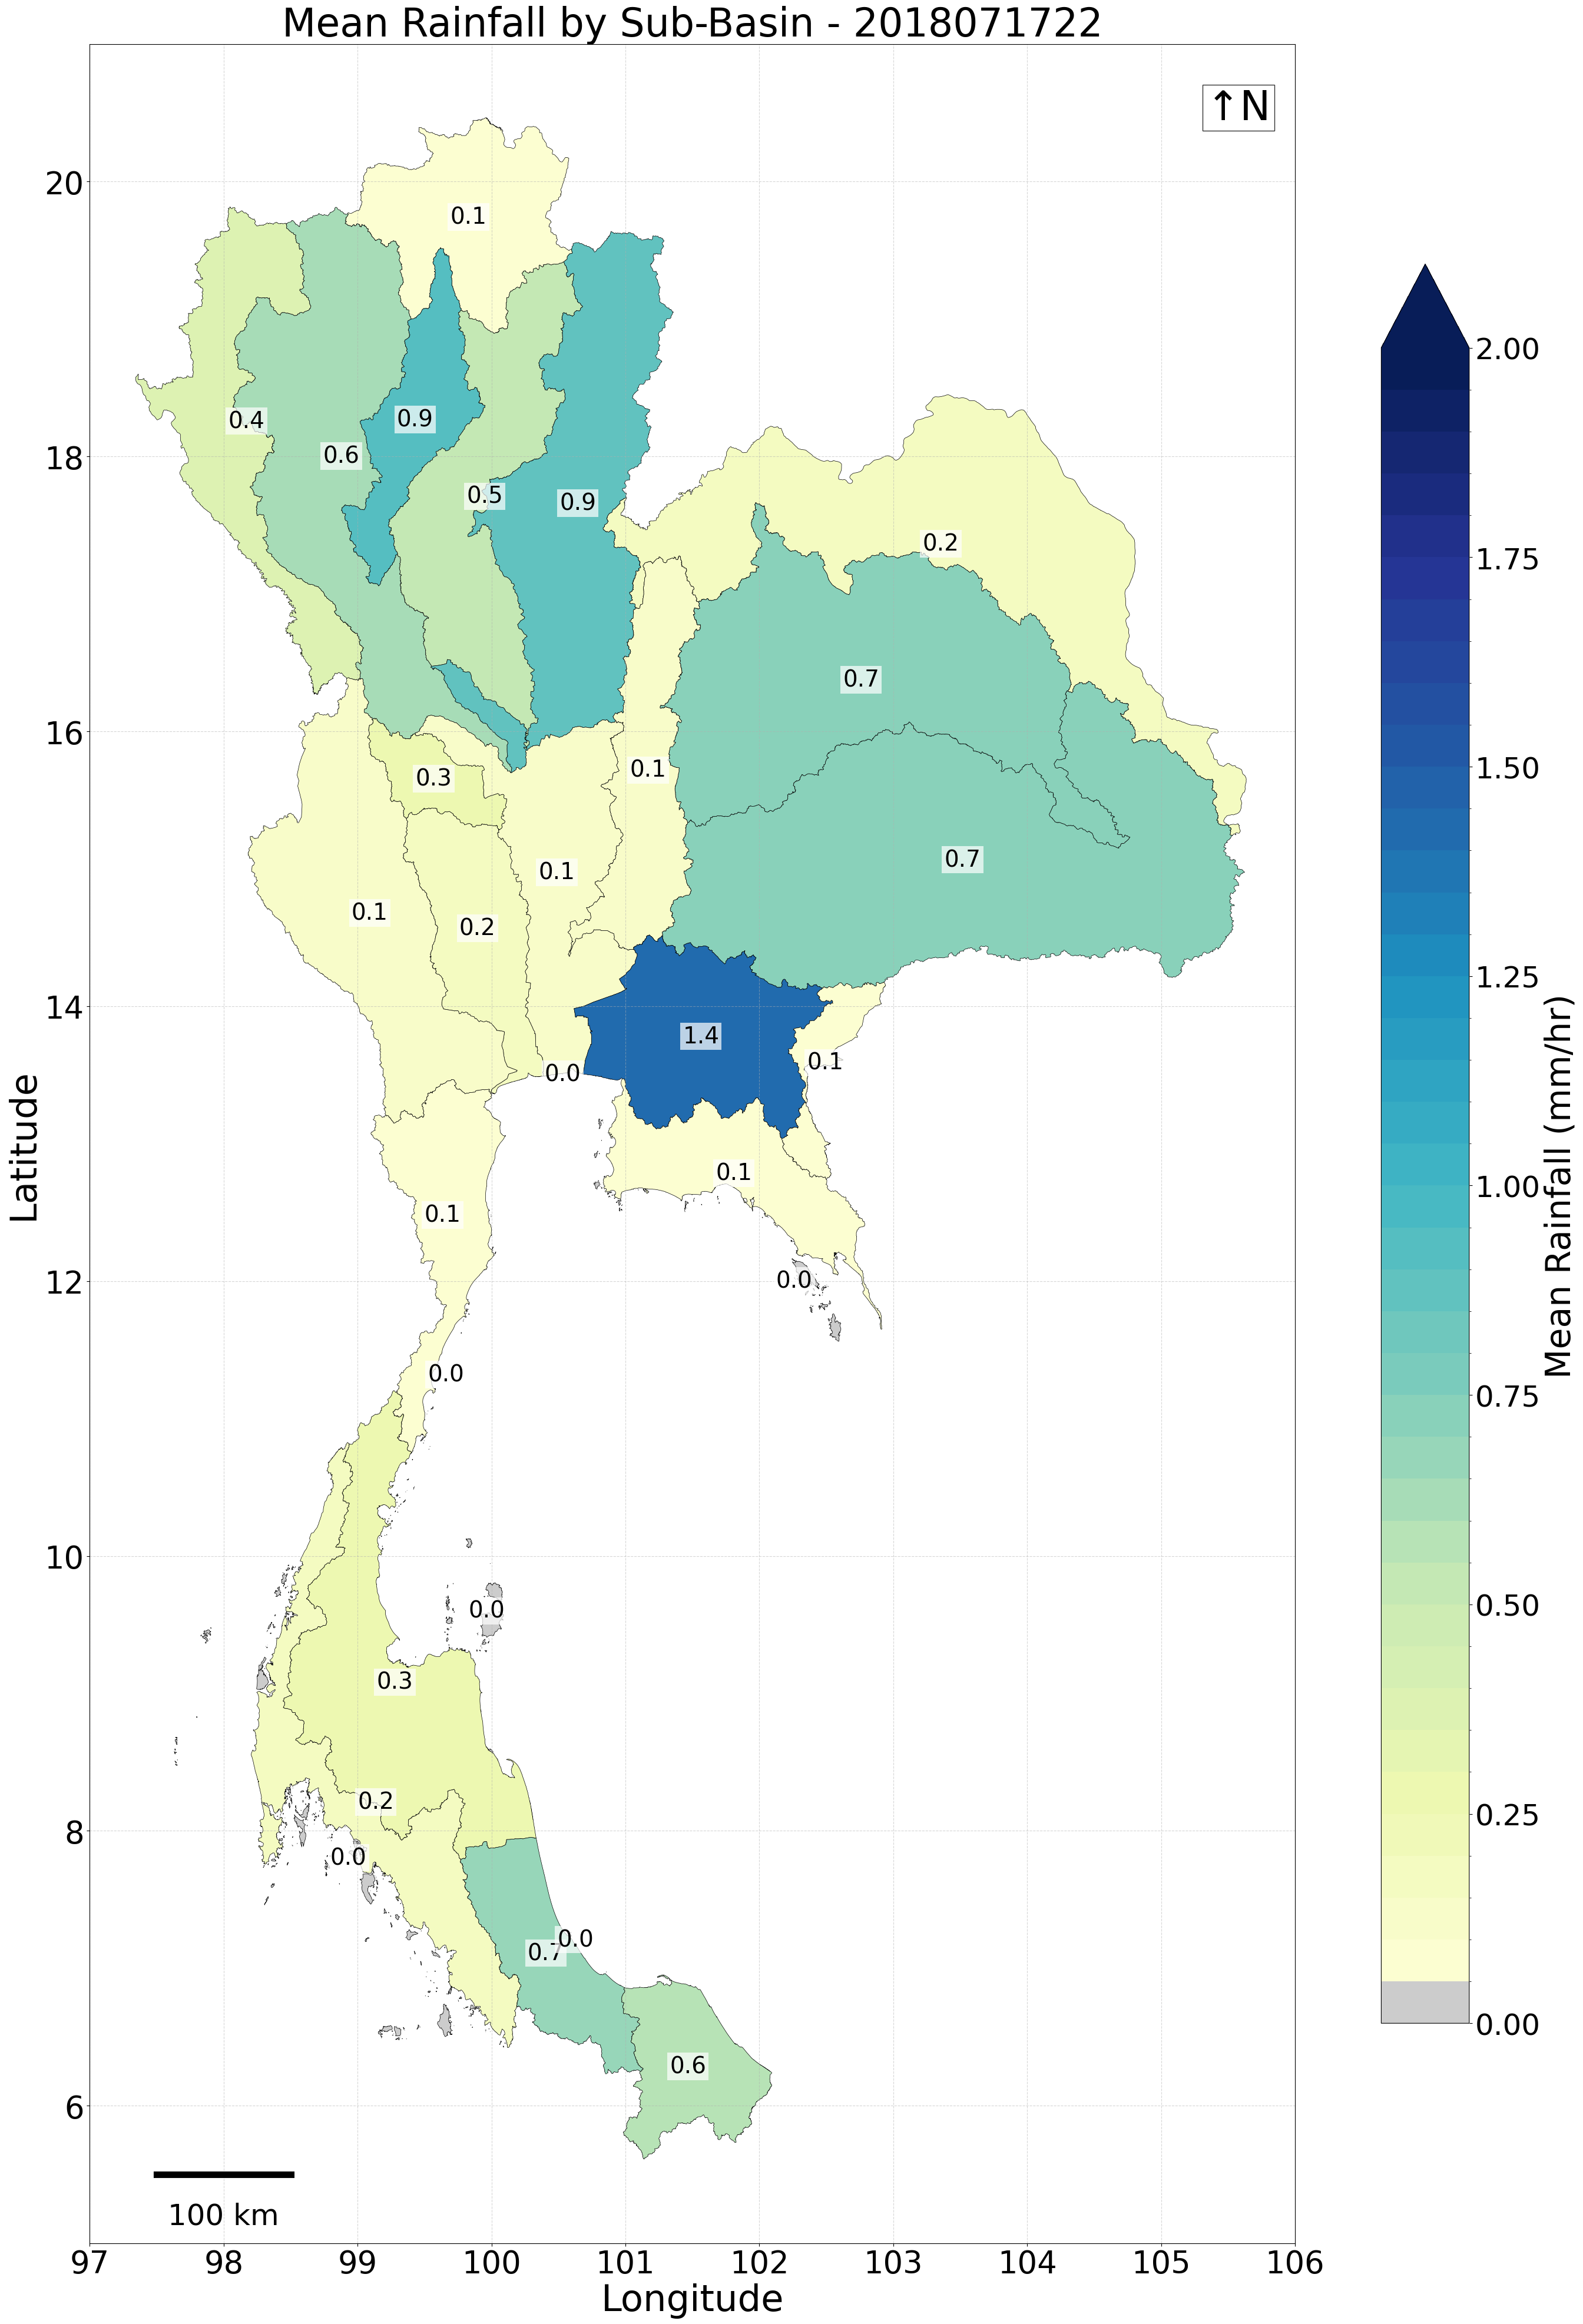

In [1]:
# ============================================================
# CELL 1 - Install required libraries
# ============================================================
!pip install rasterio geopandas pyproj -q


# ============================================================
# CELL 2 - Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
# CELL 3 - Import libraries
# ============================================================
import os
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
import rasterio
from rasterio.mask import mask
import math
import matplotlib.colors as mcolors

%matplotlib inline


# ============================================================
# CELL 4 - Set paths  (TRAINEES: only edit this cell)
# ============================================================

DATA_ROOT = "/content/drive/MyDrive/1shared_etc/000อบรมเรดาร์กรมชลประทาน/0data_radar_mos"

BASE_DIR        = f"{DATA_ROOT}/0radar_mosaic_geotif_samples/0mfb"
BASIN_SHAPEFILE = f"{DATA_ROOT}/0base_map_gis/MainBasin_ONWR_Law_WGS84Geo.shp"

TIME_HR = "2018071722"  # ← change to any single hour you want

# Output will be saved here (inside your Google Drive)
OUTPUT_DIR = f"{DATA_ROOT}/0zonal_stats_output"


# ============================================================
# CELL 5 - Verify paths (run this before main code!)
# ============================================================
print("=" * 50)
print("Checking paths...")
print(f"DATA_ROOT exists    : {os.path.exists(DATA_ROOT)}")
print(f"BASE_DIR exists     : {os.path.exists(BASE_DIR)}")
print(f"SHAPEFILE exists    : {os.path.exists(BASIN_SHAPEFILE)}")

target_file = os.path.join(BASE_DIR, f"{TIME_HR}.tif")
print(f"Target .tif exists  : {os.path.exists(target_file)}")
print(f"Target file         : {target_file}")

if os.path.exists(BASE_DIR):
    tif_files = sorted([f for f in os.listdir(BASE_DIR) if f.endswith('.tif')])
    print(f"GeoTIFF files found : {len(tif_files)}")
    if tif_files:
        print(f"First file          : {tif_files[0]}")
        print(f"Last file           : {tif_files[-1]}")
else:
    print("❌ BASE_DIR not found — check shortcut path")
print("=" * 50)


# ============================================================
# CELL 6 - Define all functions
# ============================================================

def calculate_zonal_statistics(raster_path, sub_basins_path):
    sub_basins = gpd.read_file(sub_basins_path)

    with rasterio.open(raster_path) as src:
        if sub_basins.crs != src.crs:
            sub_basins = sub_basins.to_crs(src.crs)

        def calculate_mean(geometry):
            try:
                out_image, out_transform = mask(src, [geometry], crop=True)
                out_image = out_image.squeeze()
                return np.nanmean(out_image[out_image != src.nodata])
            except ValueError:
                return np.nan

        sub_basins['mean_rainfall'] = sub_basins.geometry.apply(calculate_mean)

    return sub_basins


def plot_zonal_statistics_map(sub_basins, time_hr, output_path=None):
    valid_data = sub_basins['mean_rainfall'].dropna()

    vmin = 0
    vmax = 2
    breaks = np.linspace(vmin, vmax, 41)  # 40 classes

    colors = plt.cm.YlGnBu(np.linspace(0, 1, 256))
    colors[0] = [0.8, 0.8, 0.8, 1.0]  # grey for 0 mm
    custom_cmap = mcolors.ListedColormap(colors)
    norm = BoundaryNorm(breaks, custom_cmap.N)

    plt.rcParams.update({'font.size': 24})

    fig, ax = plt.subplots(figsize=(30, 40))

    sub_basins.plot(column='mean_rainfall', ax=ax, cmap=custom_cmap, norm=norm,
                    edgecolor='black', linewidth=0.5,
                    missing_kwds={'color': 'lightgrey'})

    ax.set_title(f'Mean Rainfall by Sub-Basin - {time_hr}', fontsize=48)

    sm = ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, extend='max', shrink=0.8)
    cbar.set_label('Mean Rainfall (mm/hr)', fontsize=42)
    cbar.ax.tick_params(labelsize=36)

    for idx, row in sub_basins.iterrows():
        if not np.isnan(row['mean_rainfall']):
            ax.annotate(text=f"{row['mean_rainfall']:.1f}",
                        xy=row.geometry.centroid.coords[0],
                        ha='center', va='center', fontsize=28,
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=3))

    ax.set_xlabel('Longitude', fontsize=45)
    ax.set_ylabel('Latitude', fontsize=45)
    ax.tick_params(axis='both', which='major', labelsize=38)
    ax.set_xlim(97, 106)
    ax.set_ylim(5, 21)
    ax.grid(True, linestyle='--', alpha=0.5)

    # North arrow
    ax.text(0.98, 0.98, '↑N', transform=ax.transAxes, ha='right', va='top', fontsize=50,
            bbox=dict(facecolor='white', edgecolor='black', alpha=0.8))

    # Scale bar
    ax.plot([97.5, 98.5], [5.5, 5.5], 'k-', linewidth=8)
    ax.text(98, 5.3, '100 km', ha='center', va='top', fontsize=36)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"✅ Map saved to: {output_path}")
    else:
        plt.show()


def main(base_dir, basin_shapefile, time_hr, output_dir):
    # Create output folders inside Google Drive
    shapefile_dir = os.path.join(output_dir, "0hourly_shapefile")
    mapplot_dir   = os.path.join(output_dir, "0hourly_mapplot")
    os.makedirs(shapefile_dir, exist_ok=True)
    os.makedirs(mapplot_dir,   exist_ok=True)

    raster_path = os.path.join(base_dir, f"{time_hr}.tif")

    if not os.path.exists(raster_path):
        print(f"❌ File not found: {raster_path}")
        return

    print(f"✅ Loading: {time_hr}.tif ...")
    sub_basins_with_stats = calculate_zonal_statistics(raster_path, basin_shapefile)

    # Save map as PNG
    output_path = os.path.join(mapplot_dir, f"{time_hr}.png")
    plot_zonal_statistics_map(sub_basins_with_stats, time_hr, output_path)

    # Save shapefile
    shapefile_output = os.path.join(shapefile_dir, f"{time_hr}.shp")
    sub_basins_with_stats.to_file(shapefile_output)
    print(f"✅ Shapefile saved to: {shapefile_output}")


# ============================================================
# CELL 7 - RUN!
# ============================================================
main(BASE_DIR, BASIN_SHAPEFILE, TIME_HR, OUTPUT_DIR)